# Section 2 — Traffic Estimation Using Sublinear Space

Real-world IDS systems cannot store complete state for every IP. This section implements three sublinear algorithms that replace expensive exact data structures — all within the 10% error budget.

**Algorithms:**
- **2a. HyperLogLog** — estimate distinct IP count using O(log n) space
- **2b. Count-Min Sketch** — identify heavy hitter destination IPs
- **2c. Bloom Filter** — approximate membership testing for blocklists

**Key concept — sublinear space:** memory grows slower than input size. Instead of storing every IP, we store fixed-size summary structures that give approximate answers with guaranteed error bounds.

In [1]:
import glob, math, time, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mmh3
from collections import Counter

csv_files = sorted(glob.glob('b/*.csv'))
print(f"Found {len(csv_files)} CSV files")

Found 6 CSV files


## (a) Estimating Unique IP Addresses - HyperLogLog

HyperLogLog uses p=10 (1024 registers) to estimate the number of distinct IPs without storing them. It hashes each IP and uses leading-zero counts to estimate cardinality.

Exact unique IPs: 34801
HLL estimated: 32034
Error rate: 7.95%
Exact time: 0.742s, HLL time: 2.565s
Exact memory: 3884.0 KB, HLL memory: 8.2 KB
Memory saving: 472x
Status: PASS (target < 10%)

Trade-off Analysis:
  Space:    HLL uses only 8.2 KB (fixed) vs 3884.0 KB for exact set (472x reduction)
  Accuracy: 7.95% error — well within the 10% budget
  Time:     HLL took 2.565s vs 0.742s for exact set
  + HLL memory is O(1) — stays fixed at 8.2 KB regardless of input size
  + Cannot retrieve the IP list or test membership — only gives cardinality
  + Increasing p (registers) lowers error but doubles memory each step


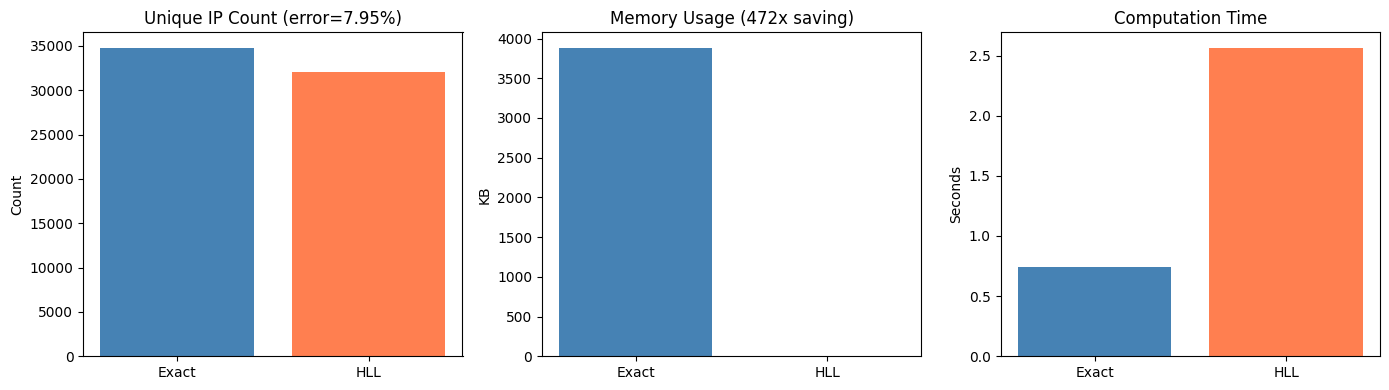

In [2]:
# HyperLogLog implementation
def hll_init(p=10):
    m = 1 << p
    return {'p': p, 'm': m, 'alpha': 0.7213 / (1 + 1.079 / m), 'registers': [0] * m}

def hll_update(hll, value):
    x = mmh3.hash(str(value), signed=False)
    j = x >> (32 - hll['p'])
    w = x & ((1 << (32 - hll['p'])) - 1)
    rank = (32 - hll['p']) - w.bit_length() + 1 if w > 0 else (32 - hll['p']) + 1
    hll['registers'][j] = max(hll['registers'][j], rank)

def hll_count(hll):
    Z = 1 / sum(2.0 ** -r for r in hll['registers'])
    E = hll['alpha'] * hll['m'] * hll['m'] * Z
    V = hll['registers'].count(0)
    if E <= 2.5 * hll['m'] and V > 0:
        E = hll['m'] * math.log(hll['m'] / V)
    return int(E)

# load IPs
df_ip = pd.concat([pd.read_csv(f, usecols=['source', 'destination']) for f in csv_files], ignore_index=True)
all_ips = pd.concat([df_ip['source'], df_ip['destination']], ignore_index=True)

# exact method
t0 = time.time()
exact_set = set(all_ips)
exact_time = time.time() - t0
exact_count = len(exact_set)
exact_mem = (sys.getsizeof(exact_set) + sum(sys.getsizeof(ip) for ip in exact_set)) / 1024

# HLL method
hll = hll_init(p=10)
t0 = time.time()
for ip in all_ips:
    hll_update(hll, ip)
hll_time = time.time() - t0
hll_count_val = hll_count(hll)
hll_mem = (sys.getsizeof(hll['registers']) + sys.getsizeof(hll)) / 1024

error = abs(exact_count - hll_count_val) / exact_count * 100

print(f"Exact unique IPs: {exact_count}")
print(f"HLL estimated: {hll_count_val}")
print(f"Error rate: {error:.2f}%")
print(f"Exact time: {exact_time:.3f}s, HLL time: {hll_time:.3f}s")
print(f"Exact memory: {exact_mem:.1f} KB, HLL memory: {hll_mem:.1f} KB")
print(f"Memory saving: {exact_mem/hll_mem:.0f}x")
print(f"Status: {'PASS' if error < 10 else 'FAIL'} (target < 10%)")

print()
print("Trade-off Analysis:")
print(f"  Space:    HLL uses only {hll_mem:.1f} KB (fixed) vs {exact_mem:.1f} KB for exact set ({exact_mem/hll_mem:.0f}x reduction)")
print(f"  Accuracy: {error:.2f}% error — well within the 10% budget")
print(f"  Time:     HLL took {hll_time:.3f}s vs {exact_time:.3f}s for exact set")
print(f"  + HLL memory is O(1) — stays fixed at {hll_mem:.1f} KB regardless of input size")
print(f"  + Cannot retrieve the IP list or test membership — only gives cardinality")
print(f"  + Increasing p (registers) lowers error but doubles memory each step")

# comparison plot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
ax1.bar(['Exact', 'HLL'], [exact_count, hll_count_val], color=['steelblue', 'coral'])
ax1.set_title(f'Unique IP Count (error={error:.2f}%)')
ax1.set_ylabel('Count')
ax2.bar(['Exact', 'HLL'], [exact_mem, hll_mem], color=['steelblue', 'coral'])
ax2.set_title(f'Memory Usage ({exact_mem/hll_mem:.0f}x saving)')
ax2.set_ylabel('KB')
ax3.bar(['Exact', 'HLL'], [exact_time, hll_time], color=['steelblue', 'coral'])
ax3.set_title('Computation Time')
ax3.set_ylabel('Seconds')
plt.tight_layout()
plt.show()

## (b) Heavy Hitters - Count-Min Sketch

CMS uses a depth x width counter table. Updates increment one cell per row; queries return the minimum across rows (overcounts but never undercounts).

In [3]:
# Count-Min Sketch implementation
def cms_init(width=10000, depth=5):
    return {'width': width, 'depth': depth, 'table': np.zeros((depth, width), dtype=np.int64)}

def cms_update(cms, x):
    for i in range(cms['depth']):
        cms['table'][i, mmh3.hash(str(x), seed=i) % cms['width']] += 1

def cms_estimate(cms, x):
    return min(cms['table'][i, mmh3.hash(str(x), seed=i) % cms['width']] for i in range(cms['depth']))

# load destination IPs
df_dst = pd.concat([pd.read_csv(f, usecols=['destination']) for f in csv_files], ignore_index=True)
dest_ips = df_dst['destination']

# exact counting
t0 = time.time()
exact_counts = Counter(dest_ips)
top_exact = exact_counts.most_common(10)
exact_time2 = time.time() - t0
exact_mem2 = (sys.getsizeof(exact_counts) + sum(sys.getsizeof(k) + sys.getsizeof(v) for k, v in exact_counts.items())) / 1024

# CMS
cms = cms_init()
t0 = time.time()
for ip in dest_ips:
    cms_update(cms, ip)
cms_time = time.time() - t0
cms_mem = cms['table'].nbytes / 1024

# compare
cms_estimates = [(ip, cms_estimate(cms, ip)) for ip, _ in top_exact]
errors = [abs(est - act) / act * 100 for (_, act), (_, est) in zip(top_exact, cms_estimates)]
avg_error = sum(errors) / len(errors)
max_error = max(errors)

print("Top 10 Destination IPs - Exact vs CMS:")
print(f"{'IP':<22} {'Exact':>10} {'CMS':>10} {'Error':>8}")
print("-" * 52)
for (ip, act), (_, est), err in zip(top_exact, cms_estimates, errors):
    print(f"{ip:<22} {act:>10,} {est:>10,} {err:>7.2f}%")

print(f"\nAverage error: {avg_error:.4f}% | Max error: {max_error:.4f}% (target < 10%)")
print(f"Exact time: {exact_time2:.3f}s, CMS time: {cms_time:.3f}s")
print(f"Exact memory: {exact_mem2:.1f} KB, CMS memory: {cms_mem:.1f} KB")
print(f"Memory saving: {exact_mem2/cms_mem:.1f}x")

print()
print("Trade-off Analysis:")
print(f"  Space:    CMS uses {cms_mem:.1f} KB (fixed) vs {exact_mem2:.1f} KB for exact counters ({exact_mem2/cms_mem:.1f}x saving)")
print(f"  Accuracy: {avg_error:.4f}% avg error — CMS never undercounts (one-sided error)")
print(f"  Time:     CMS took {cms_time:.3f}s vs {exact_time2:.3f}s for exact counting")
print(f"  + Heavy hitters have lowest relative error — ideal for identifying top destinations")
print(f"  + Increasing width reduces hash collisions (lower error) but uses more memory")
print(f"  + Increasing depth reduces failure probability but slows each update/query")

Top 10 Destination IPs - Exact vs CMS:
IP                          Exact        CMS    Error
----------------------------------------------------
198.164.30.2              232,409    232,409    0.00%
192.168.5.122             199,437    199,439    0.00%
203.73.24.75              193,200    193,202    0.00%
125.6.164.51              106,826    106,839    0.01%
67.220.214.50              49,298     49,300    0.00%
202.210.143.140            36,189     36,198    0.02%
82.98.86.183               25,214     25,215    0.00%
95.211.98.12               25,095     25,096    0.00%
209.112.44.10              21,824     21,826    0.01%
62.140.213.243             20,509     20,515    0.03%

Average error: 0.0090% | Max error: 0.0293% (target < 10%)
Exact time: 0.440s, CMS time: 3.912s
Exact memory: 3706.5 KB, CMS memory: 390.6 KB
Memory saving: 9.5x

Trade-off Analysis:
  Space:    CMS uses 390.6 KB (fixed) vs 3706.5 KB for exact counters (9.5x saving)
  Accuracy: 0.0090% avg error — CMS never unde

## (c) Bloom Filter - Membership Testing

Bloom filter uses a bit array + k hash functions. No false negatives ever, small false positive rate.

Unique source IPs to insert: 2478

Bloom filter parameters:
  Bit array size (m): 23,751 bits (23.2 KB)
  Hash functions (k): 6
  IPs inserted: 2,478

Empirical results (10,000 truly unseen test IPs):
  False positives: 89/10000 = 0.8900%
  False negatives: 0 (must be 0 — mathematical guarantee)

Memory comparison:
  Bloom filter: 23.2 KB
  Exact set:    258.9 KB
  Saving:       11.2x

Trade-off Analysis:
  Space:    11.2x memory reduction with Bloom filter
  Accuracy: Zero false negatives (guaranteed). FPR = 0.8900% (target was 1%)
  Time:     Bloom 0.003s vs Exact 0.000s
  + Constant-time O(k) lookups and insertions
  + No false negatives ever — hard mathematical guarantee
  - False positives possible (~0.89%) — rare wrong blocklist hits
  - Cannot delete items from a standard Bloom filter
  - Lowering target FPR increases memory (m grows with -ln(fpr))


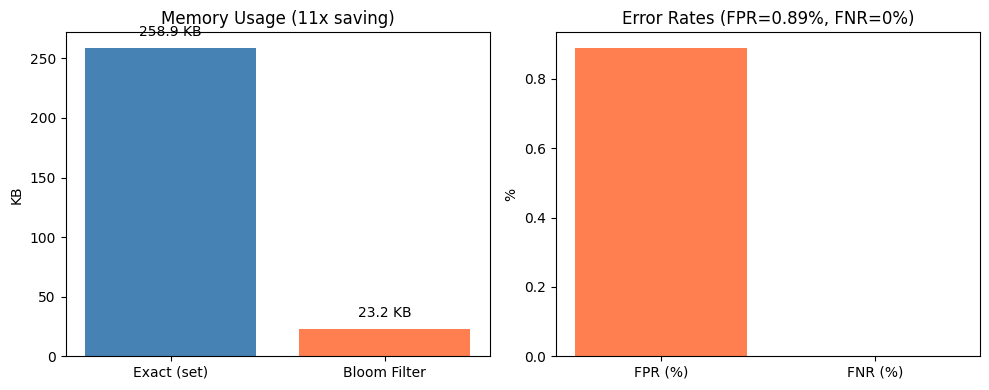

In [4]:
# Bloom filter implementation
def bloom_init(n_expected, fpr=0.01):
    """Size the filter optimally: m = -n*ln(p)/(ln2)^2, k = (m/n)*ln2"""
    m = int(-n_expected * math.log(fpr) / (math.log(2) ** 2))
    k = max(1, int((m / n_expected) * math.log(2)))
    return {'size': m, 'k': k, 'bits': np.zeros(m, dtype=bool), 'n_added': 0}

def bloom_add(b, v):
    for i in range(b['k']):
        b['bits'][mmh3.hash(str(v), seed=i) % b['size']] = True
    b['n_added'] += 1

def bloom_check(b, v):
    return all(b['bits'][mmh3.hash(str(v), seed=i) % b['size']] for i in range(b['k']))

# collect all unique source IPs from dataset
df_b = pd.concat([pd.read_csv(f, usecols=['source', 'destination']) for f in csv_files], ignore_index=True)
all_unique_ips = set(pd.concat([df_b['source'], df_b['destination']]).unique())
source_ips = list(df_b['source'].unique())

n_expected = len(source_ips)
print(f"Unique source IPs to insert: {n_expected}")

# exact set
t0 = time.time()
exact_set2 = set(source_ips)
exact_time3 = time.time() - t0
exact_mem3 = (sys.getsizeof(exact_set2) + sum(sys.getsizeof(x) for x in exact_set2)) / 1024

# bloom filter sized for expected insertions with 1% target FPR
bloom = bloom_init(n_expected=n_expected, fpr=0.01)
t0 = time.time()
for ip in source_ips:
    bloom_add(bloom, ip)
bloom_time = time.time() - t0
bloom_mem = bloom['bits'].nbytes / 1024

# test false negatives: every inserted IP must be found
fn_count = sum(1 for ip in source_ips if not bloom_check(bloom, ip))

# test false positives: generate synthetic IPs guaranteed NOT in the dataset
unseen_ips = []
for a in range(1, 256):
    for b_oct in range(0, 256):
        candidate = f"172.{a}.{b_oct}.1"
        if candidate not in all_unique_ips:
            unseen_ips.append(candidate)
        if len(unseen_ips) >= 10000:
            break
    if len(unseen_ips) >= 10000:
        break

fp_count = sum(1 for ip in unseen_ips if bloom_check(bloom, ip))
fp_rate = fp_count / len(unseen_ips) * 100

print(f"\nBloom filter parameters:")
print(f"  Bit array size (m): {bloom['size']:,} bits ({bloom_mem:.1f} KB)")
print(f"  Hash functions (k): {bloom['k']}")
print(f"  IPs inserted: {bloom['n_added']:,}")
print()
print(f"Empirical results ({len(unseen_ips):,} truly unseen test IPs):")
print(f"  False positives: {fp_count}/{len(unseen_ips)} = {fp_rate:.4f}%")
print(f"  False negatives: {fn_count} (must be 0 — mathematical guarantee)")
print()
print(f"Memory comparison:")
print(f"  Bloom filter: {bloom_mem:.1f} KB")
print(f"  Exact set:    {exact_mem3:.1f} KB")
print(f"  Saving:       {exact_mem3/bloom_mem:.1f}x")
print()
print("Trade-off Analysis:")
print(f"  Space:    {exact_mem3/bloom_mem:.1f}x memory reduction with Bloom filter")
print(f"  Accuracy: Zero false negatives (guaranteed). FPR = {fp_rate:.4f}% (target was 1%)")
print(f"  Time:     Bloom {bloom_time:.3f}s vs Exact {exact_time3:.3f}s")
print(f"  + Constant-time O(k) lookups and insertions")
print(f"  + No false negatives ever — hard mathematical guarantee")
print(f"  - False positives possible (~{fp_rate:.2f}%) — rare wrong blocklist hits")
print(f"  - Cannot delete items from a standard Bloom filter")
print(f"  - Lowering target FPR increases memory (m grows with -ln(fpr))")

# comparison chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(['Exact (set)', 'Bloom Filter'], [exact_mem3, bloom_mem], color=['steelblue', 'coral'])
ax1.set_title(f'Memory Usage ({exact_mem3/bloom_mem:.0f}x saving)')
ax1.set_ylabel('KB')
for i, v in enumerate([exact_mem3, bloom_mem]):
    ax1.text(i, v + 10, f'{v:.1f} KB', ha='center')

ax2.bar(['FPR (%)', 'FNR (%)'], [fp_rate, 0.0], color=['coral', 'steelblue'])
ax2.set_title(f'Error Rates (FPR={fp_rate:.2f}%, FNR=0%)')
ax2.set_ylabel('%')
plt.tight_layout()
plt.show()